<a href="https://colab.research.google.com/github/IssarapongB/Data-science/blob/main/%E0%B8%9B%E0%B8%A3%E0%B8%B0%E0%B8%AA%E0%B8%9E%E0%B8%81%E0%B8%B2%E0%B8%A3%E0%B8%93%E0%B9%8C%E0%B8%A7%E0%B8%B4%E0%B8%8A%E0%B8%B2%E0%B8%8A%E0%B8%B5%E0%B8%9E1_68_3_Yolo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install YOLOv5 and dependencies
!git clone https://github.com/ultralytics/yolov5
%cd yolov5
%pip install -r requirements.txt


Cloning into 'yolov5'...
remote: Enumerating objects: 18689, done.
remote: Counting objects: 100% (285/285), done.
remote: Compressing objects: 100% (161/161), done.
remote: Total 18689 (delta 233), reused 124 (delta 124), pack-reused 18404 (from 3)
Receiving objects: 100% (18689/18689), 17.68 MiB | 18.31 MiB/s, done.
Resolving deltas: 100% (12730/12730), done.
/content/yolov5
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.6 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0


Saving image.jpg to image.jpg
YOLOv5 🚀 2026-8-10 Python-3.12.13 torch-2.11.0+cpu CPU

Fusing layers... 


Using cache found in /root/.cache/torch/hub/ultralytics_yolov5_master


YOLOv5s summary: 124 layers, 7,225,885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 
image 1/1: 749x1221 3 knifes, 1 dining table, 2 scissorss
Speed: 20.2ms pre-process, 288.9ms inference, 1.9ms NMS per image at shape (1, 3, 416, 640)


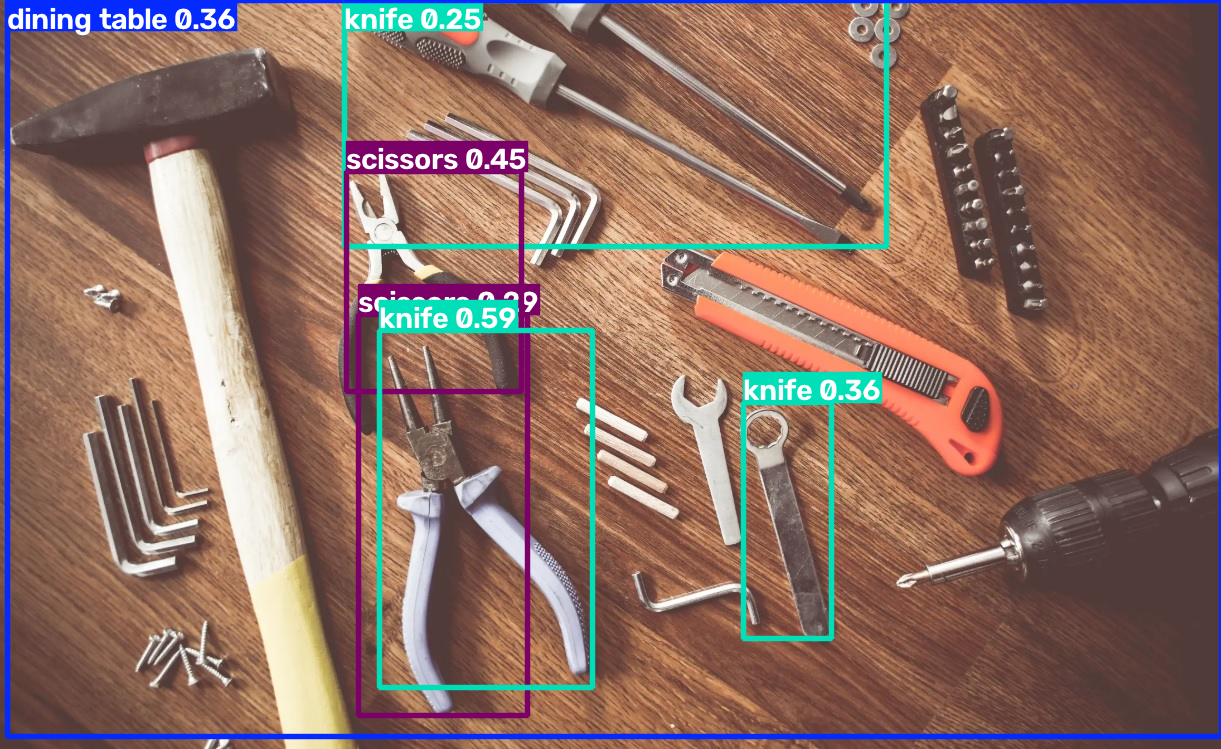

In [6]:
import torch
from matplotlib import pyplot as plt
import cv2
from PIL import Image
from google.colab import files

# 1. Upload image
uploaded = files.upload()

# Get the filename of the uploaded image
img_path = next(iter(uploaded.keys()))

# Load pre-trained YOLOv5s model
model = torch.hub.load('ultralytics/yolov5', 'yolov5s', trust_repo=True)

# Run inference
results = model(img_path)

# Show results
results.print()  # prints results in text
results.show()   # opens a window with image and boxes

In [5]:
import cv2
import torch
from tqdm import tqdm
from google.colab import files
from IPython.display import Video, display
import subprocess
import os

# 1) Upload
uploaded = files.upload()
video_path = next(iter(uploaded.keys()))
print("Input video:", video_path)

# 2) Load YOLOv5
model = torch.hub.load('ultralytics/yolov5', 'yolov5s', trust_repo=True)
model.eval()

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)
print("Device:", device)

# 3) Open video
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise RuntimeError("Cannot open input video. Try a different format (mp4/h264 recommended).")

fps = cap.get(cv2.CAP_PROP_FPS)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = fps if fps and fps > 0 else 30

# 4) Write AVI (more reliable), then convert to MP4
out_avi = "output.avi"
out_mp4 = "output.mp4"

writer = cv2.VideoWriter(out_avi, cv2.VideoWriter_fourcc(*"XVID"), fps, (width, height))
if not writer.isOpened():
    raise RuntimeError("VideoWriter failed to open. Codec not available.")

n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
pbar = tqdm(total=n_frames if n_frames > 0 else None)

with torch.inference_mode():
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # YOLO expects RGB for best accuracy
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        results = model(rgb)
        rendered = results.render()[0]  # RGB annotated
        bgr_out = cv2.cvtColor(rendered, cv2.COLOR_RGB2BGR)

        writer.write(bgr_out.astype("uint8"))
        pbar.update(1)

cap.release()
writer.release()
pbar.close()

print("Saved:", out_avi)

# 5) Convert AVI -> MP4 via ffmpeg
subprocess.run(
    ["ffmpeg", "-y", "-loglevel", "error", "-i", out_avi, "-vcodec", "libx264", "-pix_fmt", "yuv420p", out_mp4],
    check=True
)

# 6) Show files
print("\nOutput files:")
subprocess.run(["bash", "-lc", "ls -lh output.*"], check=True)

# 7) Display video inline
display(Video(out_mp4, embed=True))

Saving video.mp4 to video.mp4
Input video: video.mp4
YOLOv5 🚀 2026-8-10 Python-3.12.13 torch-2.11.0+cpu CPU

Fusing layers... 


Using cache found in /root/.cache/torch/hub/ultralytics_yolov5_master


YOLOv5s summary: 124 layers, 7,225,885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 
Device: cpu


100%|██████████| 266/266 [01:28<00:00,  3.01it/s]


Saved: output.avi

Output files:
